# Versuch 1 - Auswertung

Dieses Notebook dient dem systematischen herausschreiben der relevanten Codestellen des originalen Programms von Chiara Weckmann ```MSR_map_coil.ipynb```.
___
Erstellt am 29.Apr.2026 von Gregor Bock

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import scipy
import bfieldtools
import os
mu_0=scipy.constants.mu_0
pi=scipy.constants.pi

# Self made functions and classes
import Ausgelagerte_Funktionen_Versuchsauswertung as fkt
from Externe_Classes import Coil_Layup, Mu_material

c:\Users\grego\AppData\Local\Programs\Python\Python313\Lib\site-packages\bfieldtools\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load Experiment Data

This data was obtained on 27.Apr.2026. Therefore, coils were used on the left and right side of the MSR. They had a diameter of $d=0.34$ m, a horizontal distance of $d_x = 0.507$ m and a verticall distance of $d_z = 0.553$ m. The distances were measured with respect to the upper corners of the inner (wooden) room-side with the door.

In [2]:
# Specify folder path for .npz and points folder (.npz file should contain L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)
folder_path_points_no_current = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Experiment2\background_01_2026-05-13_10-48-57\map\points"
folder_path_points_with_current = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Experiment2\strom_10mA_mittel_07_2026-05-13_19-24-54\map\points"

# If .npz file does not hold geometric track data, specify it here
L_x = 0.800                                         # length of the mapped volume in x-direction
L_y = 0.800                                         # length of the mapped volume in y-direction
L_z = 0.400                                         # length of the mapped volume in z-direction
step_size = 0.200                                   # size of the grid steps

shift_x = 0                                         # shift of the mapped volume in x-direction
shift_y = 0                                         # shift of the mapped volume in y-direction
shift_z = 0                                         # shift of the mapped volume in z-direction

# Load data using the function "load_data_from_folder" from the "Ausgelagerte_Funktionen_Versuchsauswertung.py" file.
target_point_coord_exp, B_target_point_no_current, B_target_point_with_current = fkt.load_data_from_folder(folder_path_points_no_current, folder_path_points_with_current, L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)

Target point coordinates and B-field at target points both need to have dimension (n_points, 3).
  Shape of target coordinates: (75, 3)
  Shape of B-field with current at target points: (75, 3)
  Shape of B-field without current at target points: (75, 3)


## Plot the extracted Data

Plot each $B$-field component as well as the norm of the $B$-field of both maps (with and without coil current) directly next to each other for better comparison.

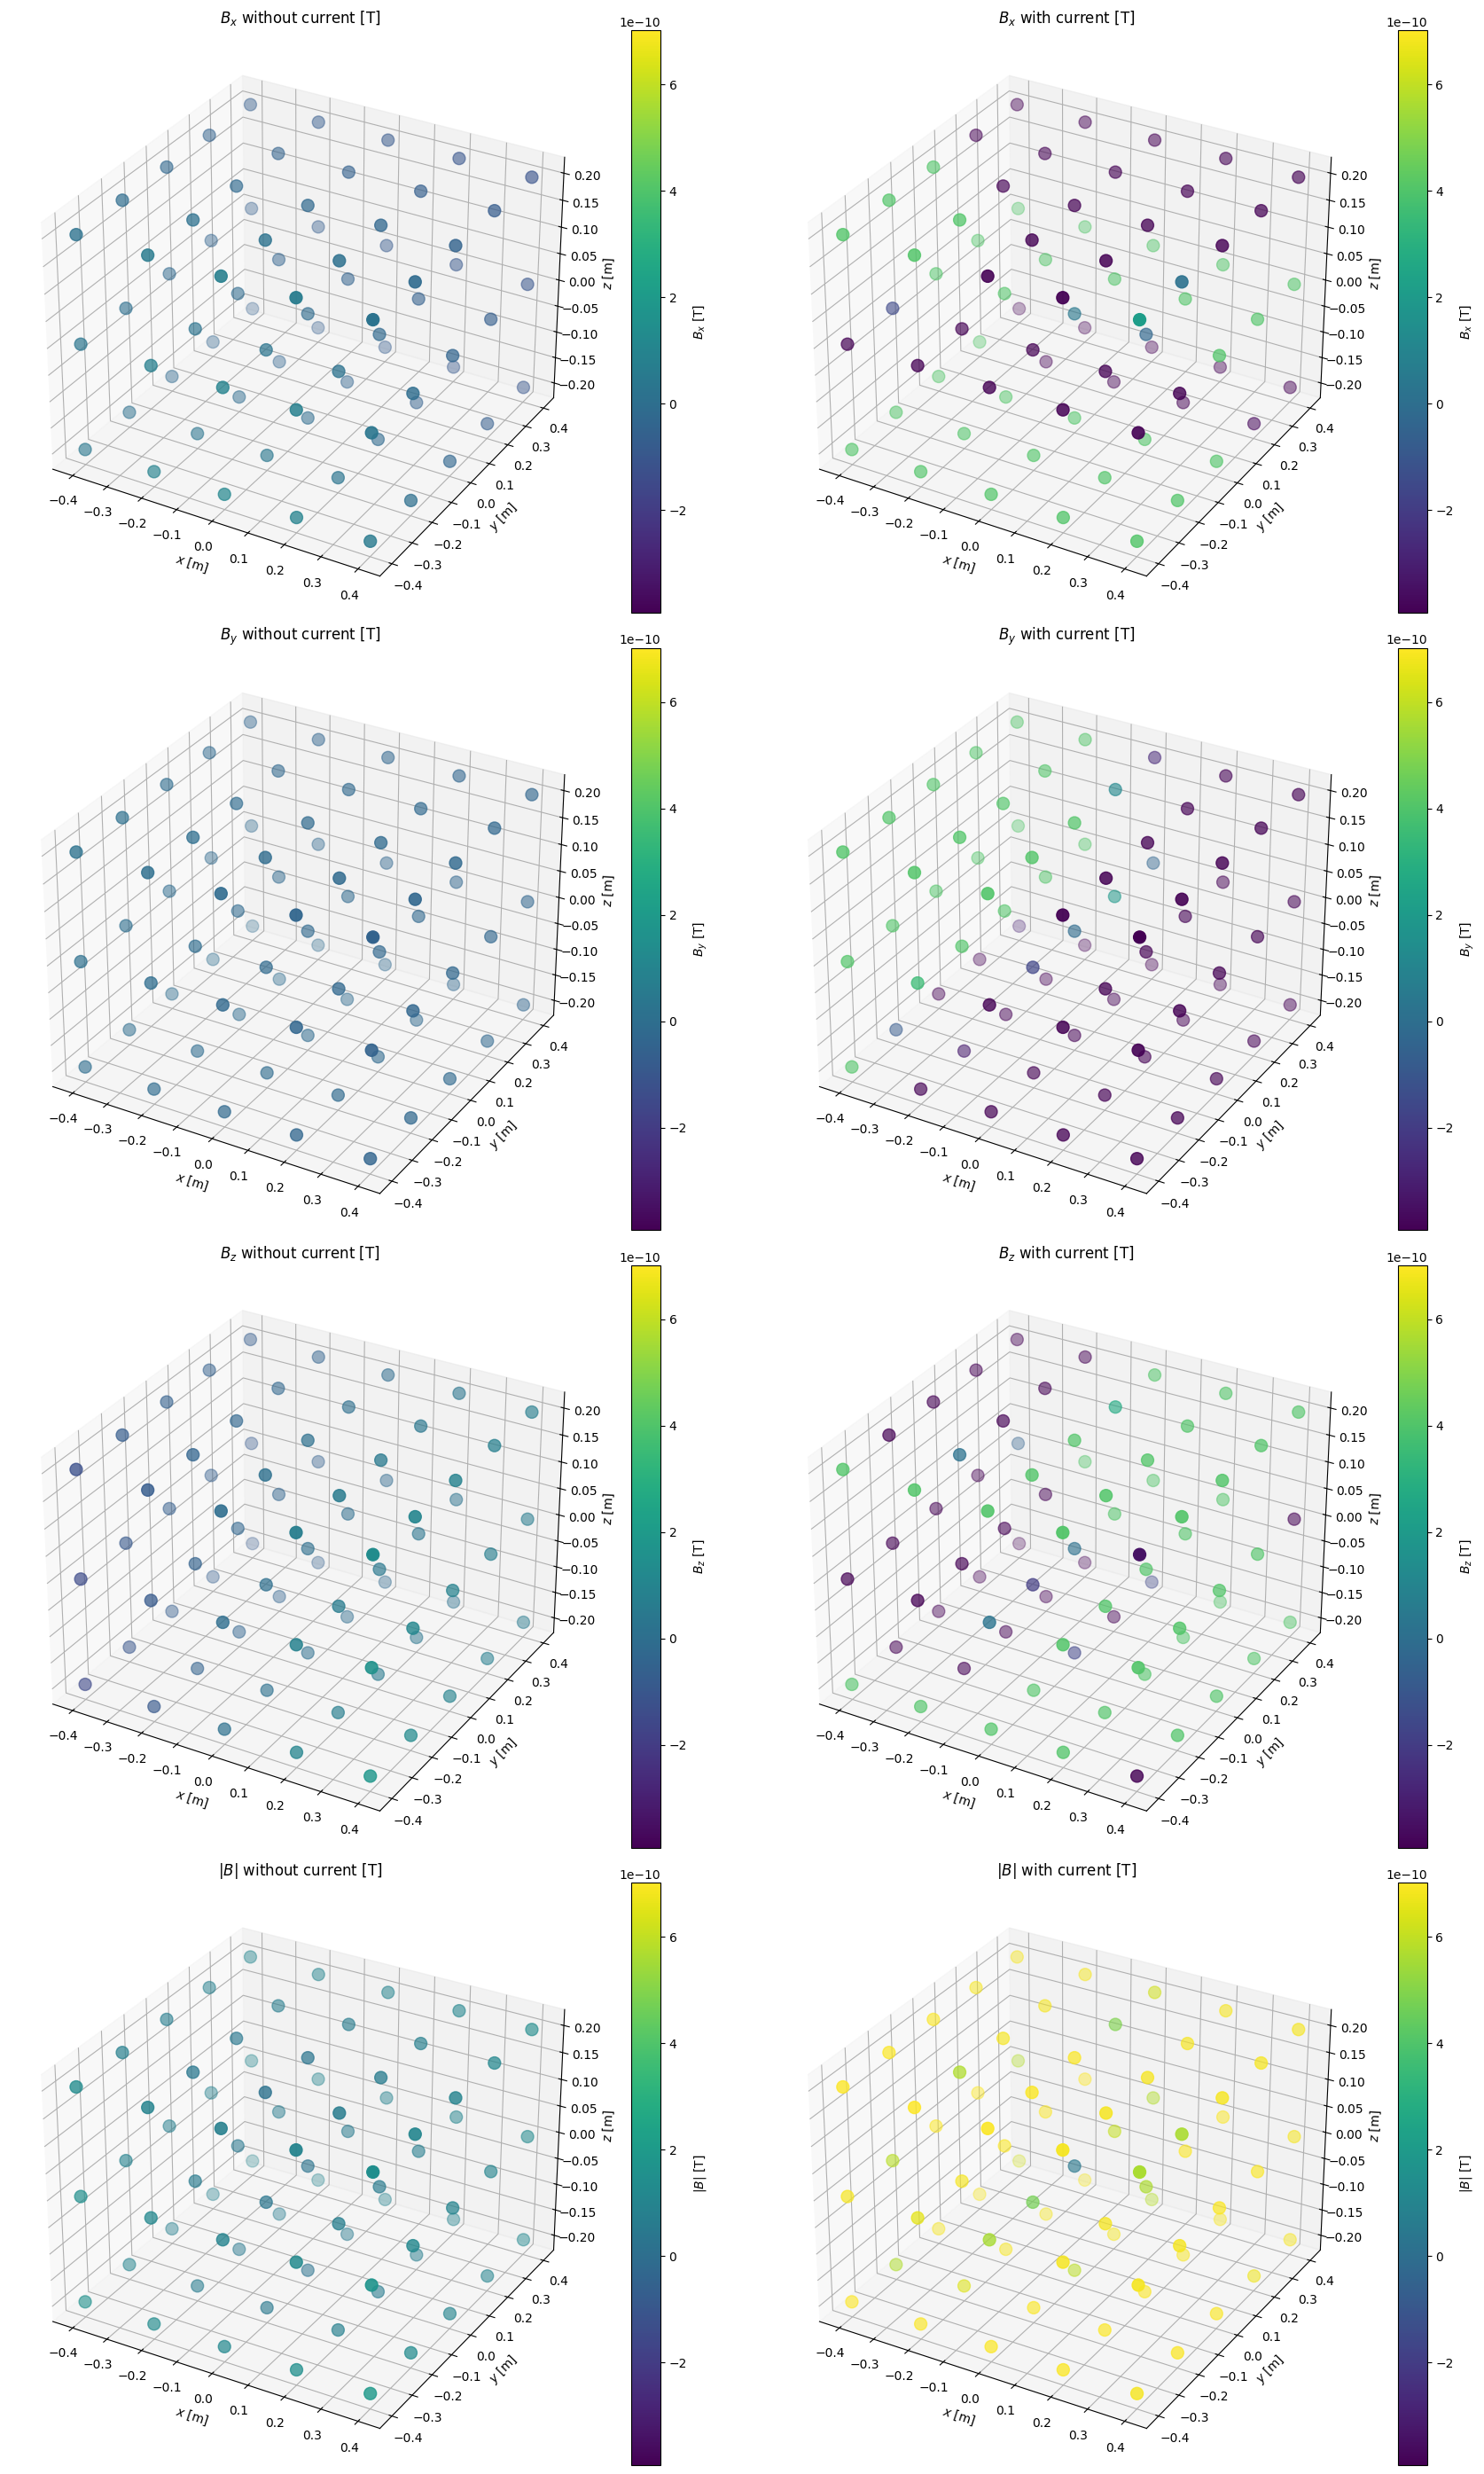

In [3]:
fkt.plot_Experiment_results_coils(target_point_coord_exp, B_target_point_no_current, B_target_point_with_current)

## Geometric Data of MSR

All geometric data of the MSR as well the coil Layup is given in meters and ampere (generally only SI-base units)!

In [4]:
# Inner shield
shield_dim = 2.3            # length, width and height of the inner most shield
shield_thickness = 1e-3     # thickness of the shield walls

# Door
door_removal = True         # Boolean which states, if the door shall be seperated in the mesh or not
door_width = 0.95           # (width of the door)
door_height = 2.004         # (height of the door)
door_offset_x = 0.2375      # (distance from door frame to right wall)
door_floor_offset = 0.0     # (distance from door frame to floor)

# Inner wood structure
height_inner_wood = 2.20    # height of the inner wooden structure
width_inner_wood = 2.34     # width of the inner wooden structure
depth_inner_wood = 2.34     # depth of the inner wooden structure

# Coil Layout
coil_diameter = 0.70                # diameter of the coils
z_dist = 0.000                      # vertical distance between coils
x_dist = 2.340                      # horizontal distance between coils (x-direction)
y_dist = 0.000                      # horizontal distance between coils (y-direction)
coil_plane_dist_to_origin_x = 1.17  # distance from the center of the room to the plane where the coils are placed in x-direction # These numbers are currently only paceholders (not correct value)
coil_plane_dist_to_origin_y = 1.17  # distance from the center of the room to the plane where the coils are placed in y-direction
coil_plane_dist_to_origin_z = 1.1   # distance from the center of the room to the plane where the coils are placed in z-direction
usable_length_x = 2.34              # usable length in x-direction for coil placement
usable_length_y = 2.34              # usable length in y-direction for coil placement
usable_length_z = 2.20              # usable length in z-direction for coil placement
n_windings = 10                     # number of windings per coil
current = 1.0                       # current in A flowing through the coils

# Note: One can give a scalar input for n_windings or current, which will be applied to every coil
#       or a list of integer numbers, which need to has the same length as coils present in the layout (if the shapes do not match, an error accours!)

# Note: If you only want to have one coil in one direction, set acourding distance to zero and useable_length slightly larger than diameter
# Note: If you want NO coil in one direction, do NOT set useable_length_{x,y,z} to zero but set {x,y,z}_dist to useable_length_{x,y,z}

# Mesh parameters:
num_calc_target_points_fine = 25        # number of target points of the magnetic field in each direction
num_calc_target_points_coarse = 5       # number of target points of the magnetic field in each direction
safety_distance = 0.05                  # Distance between coil plane and closest target point (needed to avoid errors from the assumption of infinite permeability)
refined_grid_quality_coilplane = 35     # number of initial nodes in one direction of the coil-plane (refined mesh)
coursened_grid_quality_coilplane = 12   # number of initial nodes in one direction of the coil-plane (coarsened mesh)
grid_quality_mu_metal = 12              # number of initial nodes in one direction of the mu_material plane


## Call instance to Coil_Layup class

The class ```Coil_Layup``` from the file **Externe_Classes.py** is called to give the coil geometries by inputting all the geometric data.

Furthermore, this block plots the coils which were specified by the geomertic data as well as the centers of these coils.

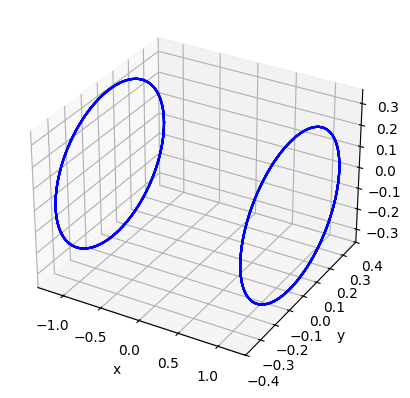

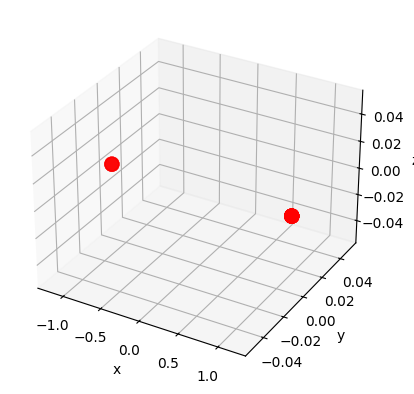

In [5]:
Coils = Coil_Layup(coil_diameter, x_dist, y_dist, z_dist, n_windings, current, coil_plane_dist_to_origin_x, coil_plane_dist_to_origin_y, coil_plane_dist_to_origin_z, usable_length_x, usable_length_y, usable_length_z)
all_circles = Coils.all_coils  # Shape: (n_coils_xy, 100, 3)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for k in range(all_circles.shape[0]):
    ax.plot(all_circles[k, :, 0], all_circles[k, :, 1], all_circles[k, :, 2], color='blue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

fig_grid = plt.figure()
ax_grid = fig_grid.add_subplot(111, projection='3d')
ax_grid.scatter(Coils.grid[:, :, 0], Coils.grid[:, :, 1], Coils.grid[:, :, 2], color='red', s=100)
ax_grid.set_xlabel('x')
ax_grid.set_ylabel('y')
ax_grid.set_zlabel('z')

plt.show()

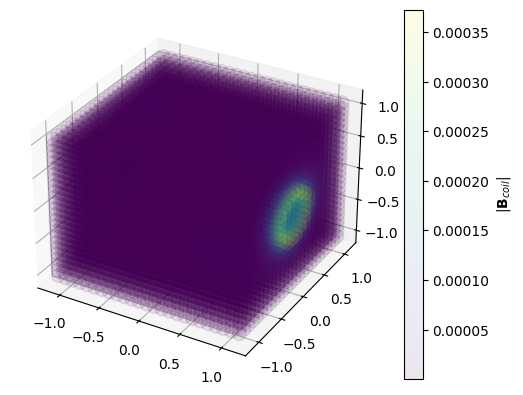

In [6]:
target_point_coord_calc_fine = fkt.calculation_target_points(num_calc_target_points_fine, coil_plane_dist_to_origin_x, coil_plane_dist_to_origin_y, coil_plane_dist_to_origin_z, safety_distance)

B_coil_predicted_fine = Coils.coil_field_by_Biot_Savart(target_point_coord_calc_fine)

# Plot
Bmag = np.linalg.norm(B_coil_predicted_fine, axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    target_point_coord_calc_fine[:, 0],
    target_point_coord_calc_fine[:, 1],
    target_point_coord_calc_fine[:, 2],
    alpha = 0.1,
    c=Bmag,
    s=100,
    cmap='viridis'
)
fig.colorbar(sc, ax=ax, label=r'$|\mathbf{B}_{coil}|$')

## Coursen target point grid

This highly resolved grid can not be used for further computations (too computationally expensive) and can also not be used to make valid comparisons with measurements, since all maps will be significantly lower! Therefore the target point grid is coursened and the Computed $B$-field (only coils) is interpolated onto it.

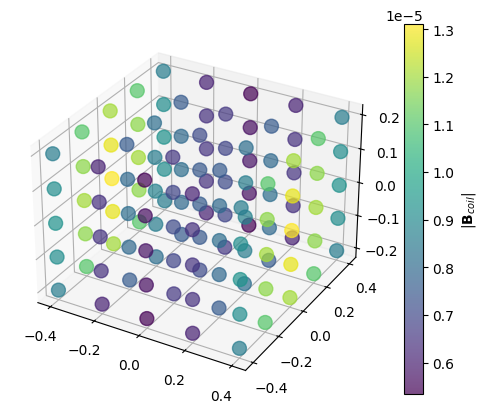

In [7]:
# Compute the target point coordinates of the coarse grid which is similar to the one typically measured in the MSR (here 5x5x5, MSR Experiments 5x5x3)
target_point_coord_calc_coarse = fkt.calculation_target_points(num_calc_target_points_coarse, L_x/2, L_y/2, L_z/2, safety_distance=0)

B_coil_predicted_coarse = Coils.coil_field_by_Biot_Savart(target_point_coord_calc_coarse)

# Plot
Bmag = np.linalg.norm(B_coil_predicted_coarse, axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    target_point_coord_calc_coarse[:, 0],
    target_point_coord_calc_coarse[:, 1],
    target_point_coord_calc_coarse[:, 2],
    alpha = 0.7,
    c=Bmag,
    s=100,
    cmap='viridis'
)
fig.colorbar(sc, ax=ax, label=r'$|\mathbf{B}_{coil}|$')

## Derive stream function from surface current

Here I compute the streamfunction directly from the surface current. The defining equation again is

\begin{equation}
    J(r) = \nabla_\parallel \psi(r) \text{ x } n
\end{equation}

Workflow:
- Create a mesh (highly resolved -> later coursening)
- Create arrays which hold the indices of those faces, which are inside, othside or directly on the coils.
- Depending on the array each face index is in, either set the streamfunction there to
    - 0 if the face is inside the coil
    - $I_{tot} * \Delta x$ if the face is inside the coil
    - $\frac{1}{2} I_{tot} * \Delta x$ if the coil intersects the face
- Since we will later need the streamfunction at each vertex, we compute the streamfunction there by averaging over all adjacent faces.

Some notes:
- It is much faster and robust than the computation via the inverse formulation of the coupling matrix and B-field
- It may have problems with very small coils as well as very small distances between cells, since the coil thickness gets very large (not representing the experiment in the best manner)
- The modeling approaches the real experiment for very small faces -> highly resolved mesh (line thickness of the coil is at least two vertices but not more than three)

Improvements:
- Define Streamfunction not wether a face is inside or outside the coil but on the condition, that a vertex is inside or outside the coil. -> This increases current density and yields a simulation closer to the actual experiment.
- The method ```.stream_function_coils``` takes only scalar input values for ```current``` and ```n_windings```. This will be improved, but has low priority at the moment.

In [8]:
Coils.create_mesh(refined_grid_quality_coilplane, door_removal, door_width, door_height, door_floor_offset, door_offset_x)

# # Plot the mesh in 2D
# x = Coils.mesh_back.vertices[:, 0]
# z = Coils.mesh_back.vertices[:, 2]
# faces = Coils.mesh_back.faces

# triang = mtri.Triangulation(x, z, faces)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.triplot(triang, color='k', linewidth=0.8)
# ax.set_aspect('equal')
# ax.set_title('XZ wall with door')
# plt.show()

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_idx=bfieldtools.utils.find_mesh_boundaries(Coils.total_planes)
# inner_vertex_idx=inner_idx[0]
# for idx in inner_vertex_idx:
#     boundary=Coils.total_planes.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')
# #fig.subplots_adjust(left=0.0, right=30.0, bottom=0.0, top=1.0)
# verts=Coils.total_planes.vertices
# ax.scatter(verts[:,0],verts[:,1],verts[:,2],alpha=0.1,label='coil planes')
# ax.scatter(target_point_coord_calc[:,0],target_point_coord_calc[:,1],target_point_coord_calc[:,2],label='MSR Map Points')
# # Axis labels
# ax.set_xlabel('x [m]')
# ax.set_ylabel('y [m]')
# ax.set_zlabel('z [m]')
# plt.legend()
# plt.tight_layout()
# plt.show()

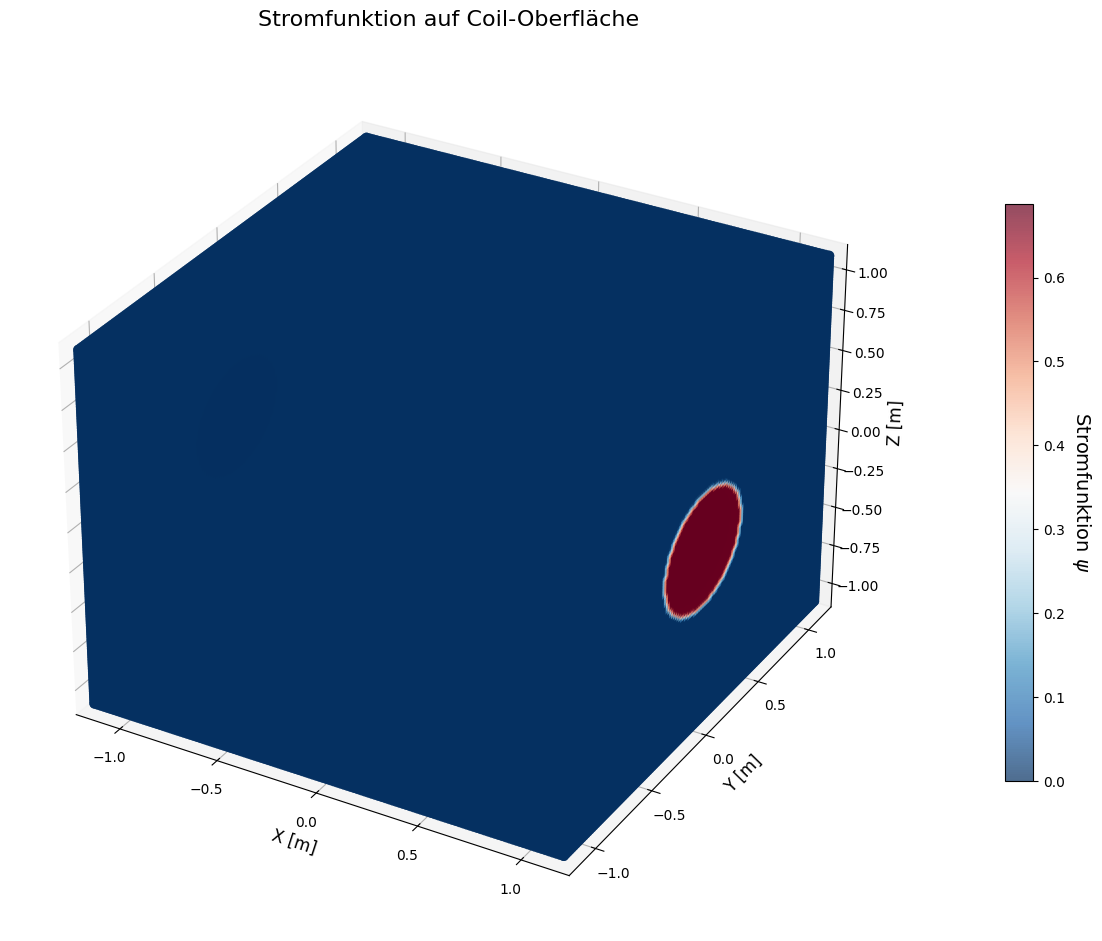

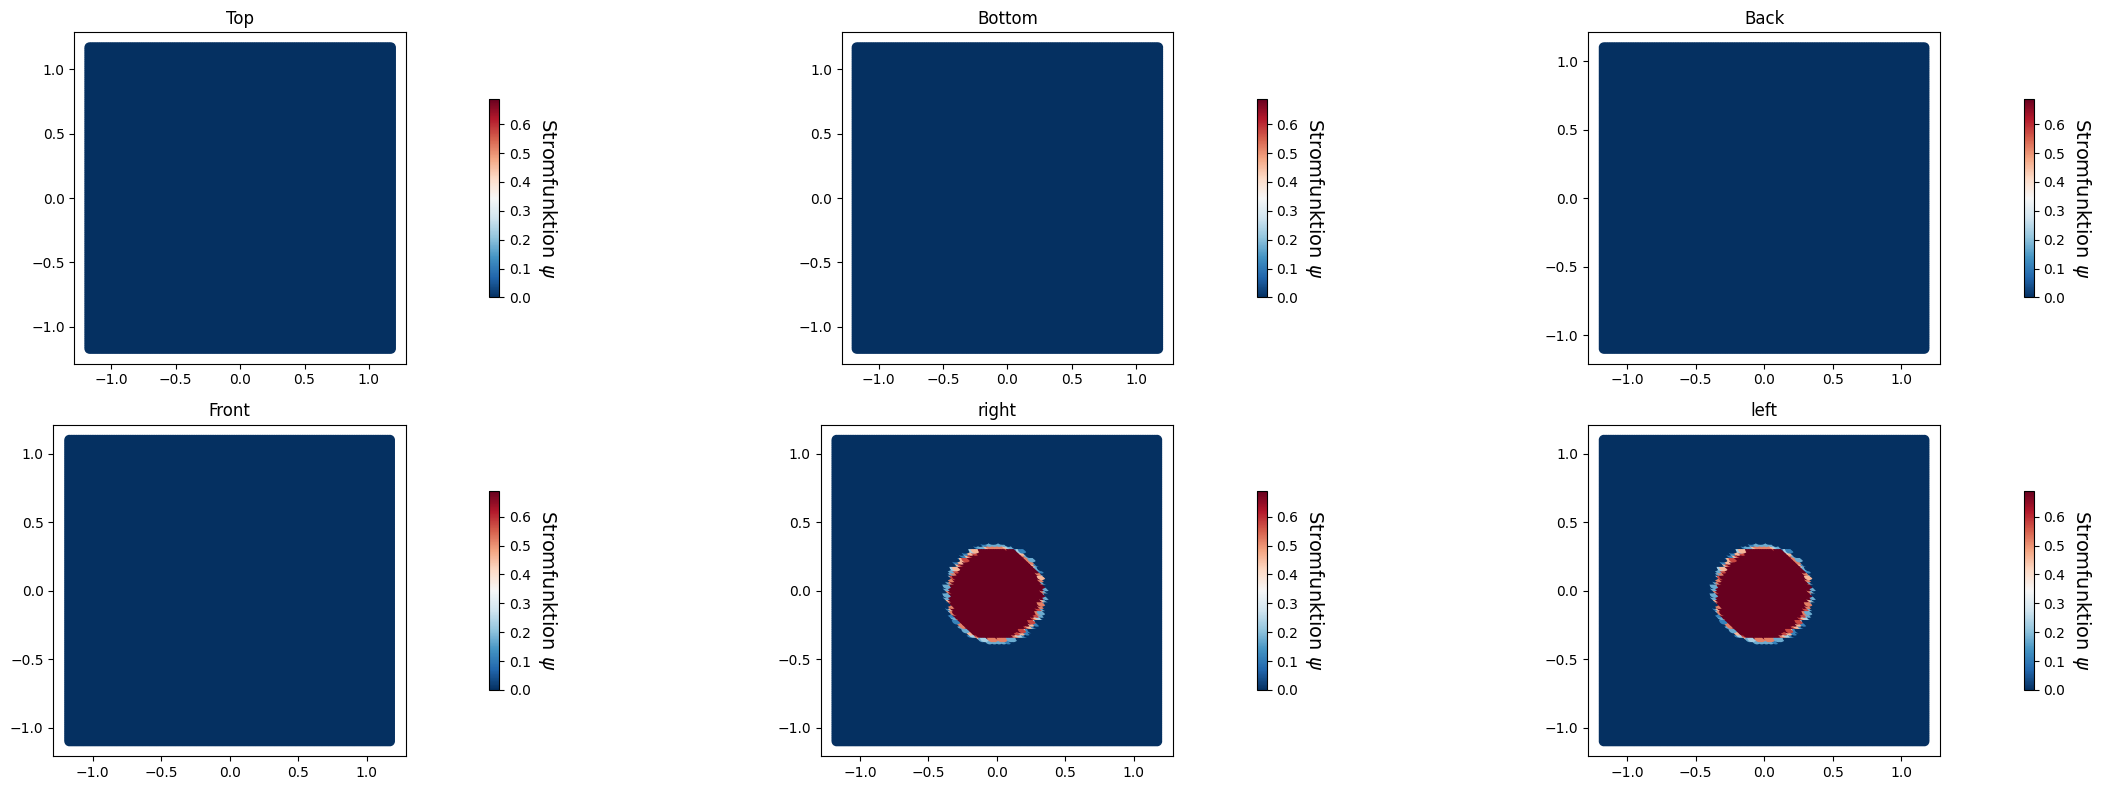

In [9]:
stream_func_coil_refined = Coils.stream_function_coils(current, n_windings)      # Note: At the moment this function only accepts scalar values for current and n_windings!!! Improvements in progress but low priority
fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_coil_refined)

## Shield meshing class

To account for the $\mu$-metal a meshed geometry accourding to the specified geometric data can be created by calling the class ```Mu_material``` from the file **Externe_Classes.py**. This will output a triangular mesh of the $\mu$-metal surface.

This block also plots the mesh (of one planar surface), the mesh boundaries (should be an empty plot) as well as the cells in 3D just as in the original programm.

In [10]:
mu_grid = Mu_material(grid_quality_mu_metal ,shield_dim, shield_thickness)

# # Plot
# # plot meshboundaries of the mu-metal
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_vertex_idx_shield = mu_grid.inner_idx[0]
# for idx in inner_vertex_idx_shield:
#     boundary=mu_grid.total_shield.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# # plot vertices
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# verts_shield = mu_grid.total_shield.vertices
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.5)

# # plot vertices of the shield and points inside the shield
# points_inside = mu_grid.total_shield.vertices - mu_grid.thickness * mu_grid.total_shield.vertex_normals
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.3)
# ax.scatter(points_inside[:,0],points_inside[:,1],points_inside[:,2],alpha=0.3)

Watertight: True
Euler number: 2
Boundary edges should have length = 0! They have length = 0


## Mesh the coil plane as well

In [11]:
total_planes = Coils.create_mesh(coursened_grid_quality_coilplane, door_removal, door_width, door_height, door_floor_offset, door_offset_x)
stream_func_coil_coarse = Coils.stream_function_coils(current, n_windings)      # Note: At the moment this function only accepts scalar values for current and n_windings!!! Improvements in progress but low priority

# # Plot the mesh in 2D
# x = Coils.mesh_back.vertices[:, 0]
# z = Coils.mesh_back.vertices[:, 2]
# faces = Coils.mesh_back.faces

# triang = mtri.Triangulation(x, z, faces)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.triplot(triang, color='k', linewidth=0.8)
# ax.set_aspect('equal')
# ax.set_title('XZ wall with door')
# plt.show()

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_idx=bfieldtools.utils.find_mesh_boundaries(Coils.total_planes)
# inner_vertex_idx=inner_idx[0]
# for idx in inner_vertex_idx:
#     boundary=Coils.total_planes.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')
# #fig.subplots_adjust(left=0.0, right=30.0, bottom=0.0, top=1.0)
# verts=Coils.total_planes.vertices
# ax.scatter(verts[:,0],verts[:,1],verts[:,2],alpha=0.1,label='coil planes')
# ax.scatter(target_point_coord_calc[:,0],target_point_coord_calc[:,1],target_point_coord_calc[:,2],label='MSR Map Points')
# # Axis labels
# ax.set_xlabel('x [m]')
# ax.set_ylabel('y [m]')
# ax.set_zlabel('z [m]')
# plt.legend()
# plt.tight_layout()
# plt.show()

## Finding the Coupling-matrix $C_{ij}$
\usepackage{amssymb}

**Prequisits**:

In the calculatetion we are using the stream function $\psi(r)$ which can be closely linked to the surface current with
\begin{gather}
    {j}({r}) = \nabla_\parallel \psi(r) \text{ x } n(r)\\
    \psi(r) - \psi(r_0) = \int_{r_0}^r j(r') \cdot (\text{d}l \text{ x } n')
\end{gather}
where current_density $j$, normal-vector $n$ and position $r$ are vectors in 3D and the stream function $\psi$ is a scalar quantity.

In the programm we define the stream function as the sum of as weight $s_i$ times a hat-function $h_i$ at every vertex $i$. The hat function is a simple function which is 1 at the vertex $i$ and zero at all other verteces. Between the verteces it gets interpolated linearly!

\begin{equation}
    \psi(r) = \sum_{i=0}^{\text{number of vertices}} s_i \cdot h_i(r)
\end{equation}

Following this we will express all obperations with the stream function $\psi$ as functions of its weights $s_i$!

**Workflow of the program**:
- Calculate scalar potential matrices $U_{coil}$ and $U_{shield}$:
\begin{equation}
    \Phi(r_i) = \sum_{j=i}^{N_{vertices}} U_{ij, \text{coil}}s_{j, \text{coil}} = -\sum_{j=i}^{N_{vertices}} U_{ij, \text{shield}}s_{j, \text{shield}}
\end{equation}
where $\Phi(r_i)$ is the scalar potential, $s_j$ is the stream function at vertex $j$ and U_{ij} is the scalar potential matrix. (See paper: Magnetic field modeling with surface currents. Part II. Implementation and usage of bfieldtools; Equation (12))

- From scalar potential matrices $U_{ij}$ compute coil-shiel-coupling matrix $M_{ij}$
\begin{gather}
    U_{shield} \cdot M_{tot\_shield} = U_{coils} \\
    s_{\text{shield}} = - U_{\text{shield}}^{-1} \cdot U_{\text{coil}} \cdot s_{\text{coil}} = M_{tot\_shield} \cdot s_{\text{coil}}
\end{gather}

- Calculate the magnetic coupling matrix $C_{ij\alpha}$ of the $\mu$-metal in all three space directions
\begin{align}
    B_{\alpha,\text{shield}}(r_k) = \sum_{i=1}^{N_{vertices}} C_{ki\alpha,\text{shield}}s_{i,\text{shield}} && \alpha \in \{x,y,z\}
\end{align}
where $B_{\alpha,\text{shield}}(r_k)$ is the magnetic field at $r_k$ in direction $\alpha$ produced by the shield, and $s_{i,\text{shield}}$ is the streamfunction in the shield at vertex $i$.

- Calculate the magnetic coupling matrix $C^*_{ij\alpha\text{shield}}$ of the $\mu$-metal as if it was caused by the coil-plane (change of reference)
 \begin{equation}
    C^*_{\alpha,\text{shield}} = C_{\alpha,\text{shield}} \cdot M_{tot\_shield}
 \end{equation}

- Calculate the magnetic coupling matrix $C^*_{ij\alpha\text{coil}}$ of the coils
\begin{align}
    B_{\alpha,\text{coil}}(r_k) = \sum_{i=1}^{N_{vertices}} C_{ki\alpha,\text{coil}}s_{i,\text{coil}} && \alpha \in \{x,y,z\}
\end{align}
where all quantities are analog to those of the shield case.

- At the boundaries of the coil plane, it holds that in any case no current can flow over the edge, resulting in a streamfunction which is constant and can be set to zero (gauge). (**Note**, that since the shield of the MSR is connected at the edges, allowing current-flow over the edge. Therefore the edges of the shield are no boundaries! This is done in the class method

- Optain the total coupling matrix $C_{ij\alpha, \text{total}}$ of both coils and shield by adding both together
\begin{equation}
    C_{ij\alpha, \text{total}} = C^*_{ij\alpha,\text{shield}} + C_{ij\alpha,\text{coil}}
\end{equation}

- Reshape the coil coupling matrix $C^*_{ij\alpha\text{coil}}$ and the total coupling matrix $C_{ij\alpha, \text{total}}$ as well as the predicted $B$-field due to the coils alone to better use it later on (shape: N, 3, M -> 3N, M)



In [12]:
# Run these few lines in extra code block since they take a while to execute!
# Scalar-Potential Coupling Matrix U_{ij} (only dependent on geometrical data of meshes)
    # mu-material
U_coupling_shield_inside = bfieldtools.mesh_magnetics.scalar_potential_coupling(mu_grid.total_shield, mu_grid.points_inside)
    # Coils
U_coupling_coils_inside = bfieldtools.mesh_magnetics.scalar_potential_coupling(Coils.total_planes, mu_grid.points_inside)

# total shield coupling which links the coil plane to the shield plane U_shield * M = U_coil
Coil_Shield_coupling = np.linalg.solve(U_coupling_shield_inside, U_coupling_coils_inside)

# B-field coupling matrix C_shield of the shield alone (only dependent on gemetrical data of mu-mesh and target point coordinates)
Coupling_shield = bfieldtools.mesh_magnetics.magnetic_field_coupling(mu_grid.total_shield, target_point_coord_calc_fine)

Computing scalar potential coupling matrix, 11618 vertices by 11618 target points... took 128.14 seconds.
Computing scalar potential coupling matrix, 12150 vertices by 11618 target points... took 123.61 seconds.
Computing magnetic field coupling matrix, 11618 vertices by 15625 target points... took 104.71 seconds.


In [13]:
# B-field coupling matrix C*_shield of the shield alone, seen as a secondary source from the coil plane perspective C*_shield = C_shield * M
secondary_Coupling_shield = np.tensordot(Coupling_shield, Coil_Shield_coupling, axes=([2],[0]))

# B-field coupling matrix C_coil of the coil plane (only dependent on gemetrical data of coil-mesh and target point coordinates)
Coupling_coil = bfieldtools.mesh_magnetics.magnetic_field_coupling(Coils.total_planes, r = target_point_coord_calc_fine)

# Note: Not sure if this is correct!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! -> see Markdown above!
inner_idx = bfieldtools.utils.find_mesh_boundaries(Coils.total_planes)
inner_vertex_idx = inner_idx[0]
for idx in inner_vertex_idx:
    Coupling_coil[:, :, idx] = 0

# Combined coupling matrix C_total which incorporates the effect of the shield as a secondary source and the coil plane as a primary source
total_Coupling = Coupling_coil - secondary_Coupling_shield # Note: The minus here is directly from the equation in the paper (see markdown)

# Suppose C_coil has shape (N, 3, M) (N...number of target points, M...number of vertices in coil plane)
N, _, M = Coupling_coil.shape
Coupling_coil_flat = Coupling_coil.reshape(3 * N, M)

# Suppose C_tot has shape (N, 3, M) (N...number of target points, M...number of vertices in coil plane)
N, _, M = total_Coupling.shape
total_Coupling_flat = total_Coupling.reshape(3 * N, M)

# Suppose B_predicted has shape (N, 3) (N...number of target points)
N, _ = B_coil_predicted_fine.shape
B_coil_predicted_flat = B_coil_predicted_fine.reshape(3 * N)

# Debug
print(f'Shapes of the different matrices:\n   U_coupling_shield_inside: {U_coupling_shield_inside.shape}\n   U_coupling_coils_inside: {U_coupling_coils_inside.shape}\n   Coil_Shield_coupling: {Coil_Shield_coupling.shape}\n   B_coupling_shield: {Coupling_shield.shape}\n   secondary_Coupling_shield: {secondary_Coupling_shield.shape}\n   Coupling_coil: {Coupling_coil.shape}\n   total_Coupling: {total_Coupling.shape}\n   Coupling_coil_flat: {Coupling_coil_flat.shape}\n   total_Coupling_flat: {total_Coupling_flat.shape}')

Computing magnetic field coupling matrix, 12150 vertices by 15625 target points... took 105.07 seconds.
Shapes of the different matrices:
   U_coupling_shield_inside: (11618, 11618)
   U_coupling_coils_inside: (11618, 12150)
   Coil_Shield_coupling: (11618, 12150)
   B_coupling_shield: (15625, 3, 11618)
   secondary_Coupling_shield: (15625, 3, 12150)
   Coupling_coil: (15625, 3, 12150)
   total_Coupling: (15625, 3, 12150)
   Coupling_coil_flat: (46875, 12150)
   total_Coupling_flat: (46875, 12150)


## Convert coil current into stream function

- In a first step, we find the stream function of the coils making use of
\begin{equation}
    B_{\text{coil}} = C_{\text{coil}} \cdot s_{\text{coil}}
\end{equation}
<span style="color:red">Are there improvements to this? I don`t understand the whole code! Why is the Laplace grid used? What do changes in ```lambda_reg``` do?</span>

- Using the fact that
\begin{gather}
    B_{\text{tot}} = B_{\text{coil}} + B_{\text{shield}} = C_{\text{coil}} \cdot s_{\text{coil}} + C_{\text{shield}} \cdot s_{\text{shield}} \\
    = (C_{\text{coil}} - C_{\text{shield}}\cdot U_{\text{shield}}^{-1}\cdot U_{\text{coil}}) s_{\text{coil}} 
\end{gather}
the total magnetic field can directly be computed!

Shapes of the different matrices:
   Stream function of coils: (12150,)
   B_tot_flat: (46875,)
   B_tot: (15625, 3)


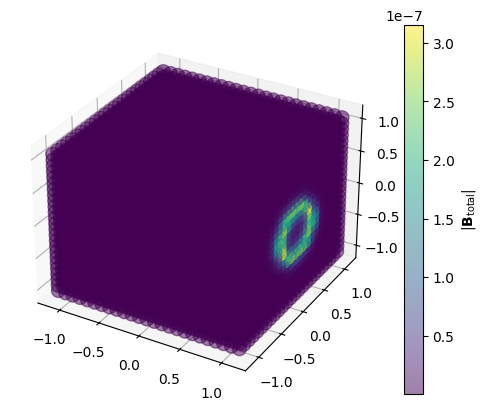

In [14]:
# Compute stream function due to coils (This only needs to be done, if there is no analytical solution already calculated)
# stream_func_coil, _, _, _ = np.linalg.lstsq(Coupling_coil_flat, B_coil_predicted_flat, rcond=None) # -> Are there improvements to s? And if yes, how? Chiara said something

# Use coil stream function and total coupling matrix to compute total magnetic field
B_tot_flat = total_Coupling_flat @ stream_func_coil_coarse

# Extract values in B_tot_flat of shape (3*number_target_points) into B_tot of shape (number_target_points, 3)
N, _ = B_coil_predicted_fine.shape       # N = number_of_target_points
B_tot = B_tot_flat.reshape(N, 3)    # B_tot has shape (number_target_points, 3)

# Debug
print(f'Shapes of the different matrices:\n   Stream function of coils: {stream_func_coil_coarse.shape}\n   B_tot_flat: {B_tot_flat.shape}\n   B_tot: {B_tot.shape}')

# Plots

fig_B_tot = plt.figure()
ax_B_tot = fig_B_tot.add_subplot(111, projection='3d')
sc_B_tot = ax_B_tot.scatter(
    target_point_coord_calc_fine[:, 0],
    target_point_coord_calc_fine[:, 1],
    target_point_coord_calc_fine[:, 2],
    c=np.linalg.norm(B_tot, axis=1),
    s=100,
    cmap='viridis',
    alpha = 0.5,
)
fig_B_tot.colorbar(sc_B_tot, ax=ax_B_tot, label=r'$|\mathbf{B}_{\text{total}}|$')

# Save to .npz with named keys
file_dir = os.path.dirname(folder_path_points_with_current)
parent_dir = os.path.dirname(file_dir)
filename = 'B_tot_results\\B_tot_rault_' + os.path.basename(parent_dir) + '.npz'

np.savez(filename, B_field=B_tot, points=target_point_coord_calc_fine)

# Evaluation

Make nice plots and Sanity checks here!

## Second Experiment

Compare measured and calculated $B$-field in $x$-direction along the (-0.4, 0, 0) -- (0.4, 0, 0) line. To compare all measurements, print the required Data of each experiment and plot the numerical values which were printed.

The values of the measured $B$ field in $x$-direction along the $x$-axis is:
   [np.float64(4.050762714941006e-10), np.float64(4.050762714941006e-10), np.float64(4.35303526626699e-11), np.float64(-3.225624892733304e-11), np.float64(4.050762714941006e-10)]
The accourding $x$-coordinates are:
   [np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)]
The values of the calculated $B$ field in $x$-direction along the $x$-axis is:
   [np.float64(7.795918942308779e-10), np.float64(5.00286297214758e-10), np.float64(3.375997325226671e-10), np.float64(2.4532096662316467e-10), np.float64(1.9815705088283033e-10), np.float64(1.8367746616417907e-10), np.float64(1.9815705048014583e-10), np.float64(2.453209657307546e-10), np.float64(3.3759973093635464e-10), np.float64(5.002862945393227e-10), np.float64(7.795918897282292e-10)]
The accourding $x$-coordinates are:
   [np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666

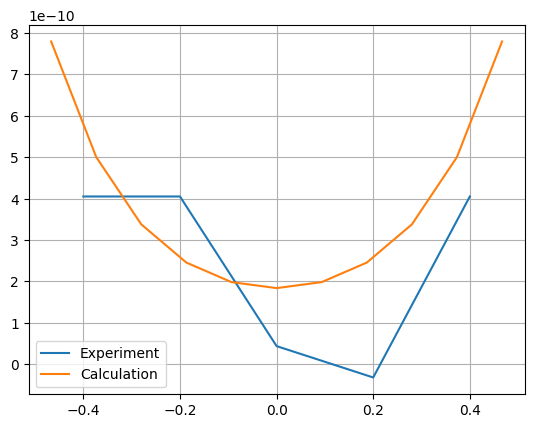

In [15]:
B_x_exp = []
x_exp = []
for i in range(len(target_point_coord_exp)):
    if target_point_coord_exp[i, 1] == 0 and target_point_coord_exp[i, 2] == 0:
        x_exp.append(target_point_coord_exp[i, 0])
        B_x_exp.append(B_target_point_with_current[i, 0])

print(f'The values of the measured $B$ field in $x$-direction along the $x$-axis is:\n   {B_x_exp}\nThe accourding $x$-coordinates are:\n   {x_exp}')

B_x_calc = []
x_calc = []
for i in range(len(target_point_coord_calc_fine)):
    if target_point_coord_calc_fine[i, 1] == 0 and target_point_coord_calc_fine[i, 2] == 0 and target_point_coord_calc_fine[i, 0] < 0.5 and target_point_coord_calc_fine[i, 0] > -0.5:
        x_calc.append(target_point_coord_calc_fine[i, 0])
        B_x_calc.append(B_tot[i, 0])
print(f'The values of the calculated $B$ field in $x$-direction along the $x$-axis is:\n   {B_x_calc}\nThe accourding $x$-coordinates are:\n   {x_calc}')

print(f'The length of both lists are:\n   Experiment: B_x(y=0; z=0): {len(B_x_exp)}\n   Calculation: B_x(y=0; z=0): {len(B_x_calc)}')


plt.plot(x_exp, B_x_exp, label = 'Experiment')
plt.plot(x_calc, B_x_calc, label = 'Calculation')
plt.grid()
plt.legend()
plt.show()

TypeError: array() missing required argument 'object' (pos 0)

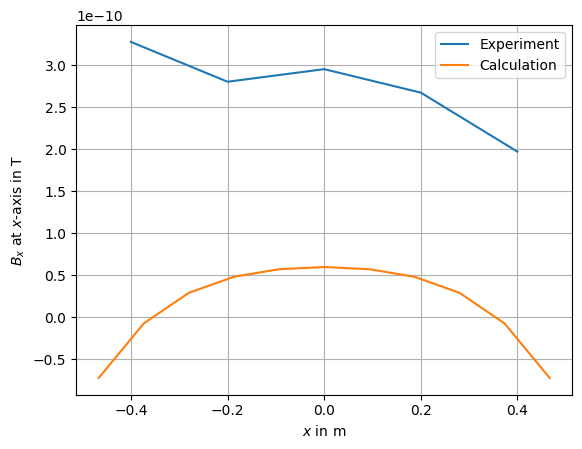

In [ ]:
# Plot the 4-coil configuration from the first experiment
# The data is copied from the analysis
plot_4Coils_B_x_exp = np.array([np.float64(3.2769018659600506e-10), np.float64(2.80300082214389e-10), np.float64(2.952930998286635e-10), np.float64(2.673477703538443e-10), np.float64(1.9714566001734268e-10)])
plot_4Coils_x_exp = np.array([np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)])
plot_4Coils_B_x_calc = np.array([np.float64(-7.211382328309132e-11), np.float64(-7.242004546882726e-12), np.float64(2.9170401575287294e-11), np.float64(4.8280695327582826e-11), np.float64(5.7235051401315004e-11), np.float64(5.982868626754522e-11), np.float64(5.7235048587403344e-11), np.float64(4.828068922360924e-11), np.float64(2.917039107995474e-11), np.float64(-7.2420215405818875e-12), np.float64(-7.21138507415066e-11)])
plot_4Coils_x_calc = np.array([np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666666666666665), np.float64(-0.09333333333333327), np.float64(0.0), np.float64(0.09333333333333327), np.float64(0.18666666666666676), np.float64(0.28), np.float64(0.3733333333333333), np.float64(0.46666666666666656)])

fig_4_coils, ax_4_coils = plt.subplots()
ax_4_coils.plot(plot_4Coils_x_exp, plot_4Coils_B_x_exp, label = 'Experiment')
ax_4_coils.plot(plot_4Coils_x_calc, plot_4Coils_B_x_calc, label = 'Calculation')
ax_4_coils.set_xlabel(r'$x$ in m')
ax_4_coils.set_ylabel(r'$B_x$ at $x$-axis in T')
ax_4_coils.grid()
ax_4_coils.legend()

# Plot the large coil configuration with multiple different currents
plot_05mA_mittel_B_x_exp = np.array([np.float64(3.2019608086111963e-10), np.float64(8.34437399770282e-11), np.float64(-2.0730429765777478e-11), np.float64(-2.1059245523404497e-11), np.float64(8.329021480181402e-11)])
plot_05mA_mittel_x_exp = np.array([np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)])
plot_05mA_mittel_B_x_calc = np.array([np.float64(7.795918942318007e-10), np.float64(5.002862972156208e-10), np.float64(3.375997325233907e-10), np.float64(2.453209666237078e-10), np.float64(1.981570508831928e-10), np.float64(1.8367746616442635e-10), np.float64(1.9815705048033073e-10), np.float64(2.453209657309825e-10), np.float64(3.3759973093676487e-10), np.float64(5.002862945401146e-10), np.float64(7.795918897297106e-10)])
plot_05mA_mittel_x_calc = np.array([np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666666666666665), np.float64(-0.09333333333333327), np.float64(0.0), np.float64(0.09333333333333327), np.float64(0.18666666666666676), np.float64(0.28), np.float64(0.3733333333333333), np.float64(0.46666666666666656)])

plot_1mA_mittel_B_x_exp = np.array([np.float64(2.627498286377756e-10), np.float64(9.007891411181429e-11), np.float64(-8.991345433124715e-12), np.float64(-1.307820950959987e-11), np.float64(7.908660491972237e-11)])
plot_1mA_mittel_x_exp = np.array([np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)])
plot_1mA_mittel_B_x_calc = np.array([np.float64(7.795918942332598e-10), np.float64(5.002862972168702e-10), np.float64(3.375997325247165e-10), np.float64(2.453209666253032e-10), np.float64(1.9815705088517407e-10), np.float64(1.8367746616684668e-10), np.float64(1.9815705048318621e-10), np.float64(2.453209657341903e-10), np.float64(3.375997309401624e-10), np.float64(5.002862945434218e-10), np.float64(7.795918897324597e-10)])
plot_1mA_mittel_x_calc = np.array([np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666666666666665), np.float64(-0.09333333333333327), np.float64(0.0), np.float64(0.09333333333333327), np.float64(0.18666666666666676), np.float64(0.28), np.float64(0.3733333333333333), np.float64(0.46666666666666656)])

plot_5mA_mittel_B_x_exp = np.array([np.float64(4.050762714941006e-10), np.float64(4.050762714941006e-10), np.float64(4.519705560900834e-12), np.float64(-4.520632006074904e-15), np.float64(4.050762714941006e-10)])
plot_5mA_mittel_x_exp = np.array([np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)])
plot_5mA_mittel_B_x_calc = np.array([np.float64(7.795918942316153e-10), np.float64(5.002862972156428e-10), np.float64(3.3759973252375637e-10), np.float64(2.4532096662450703e-10), np.float64(1.9815705088444825e-10), np.float64(1.8367746616612584e-10), np.float64(1.9815705048241975e-10), np.float64(2.4532096573333485e-10), np.float64(3.3759973093918044e-10), np.float64(5.002862945422852e-10), np.float64(7.795918897311521e-10)])
plot_5mA_mittel_x_calc = np.array([np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666666666666665), np.float64(-0.09333333333333327), np.float64(0.0), np.float64(0.09333333333333327), np.float64(0.18666666666666676), np.float64(0.28), np.float64(0.3733333333333333), np.float64(0.46666666666666656)])

plot_10mA_mittel_B_x_exp = np.array([np.float64(4.050762714941006e-10), np.float64(4.050762714941006e-10), np.float64(4.35303526626699e-11), np.float64(-3.225624892733304e-11), np.float64(4.050762714941006e-10)])
plot_10mA_mittel_x_exp = np.array([np.float64(-0.4), np.float64(-0.2), np.float64(0.0), np.float64(0.2), np.float64(0.4)])
plot_10mA_mittel_B_x_calc = np.array([np.float64(7.795918942308779e-10), np.float64(5.00286297214758e-10), np.float64(3.375997325226671e-10), np.float64(2.4532096662316467e-10), np.float64(1.9815705088283033e-10), np.float64(1.8367746616417907e-10), np.float64(1.9815705048014583e-10), np.float64(2.453209657307546e-10), np.float64(3.3759973093635464e-10), np.float64(5.002862945393227e-10), np.float64(7.795918897282292e-10)])
plot_10mA_mittel_x_calc = np.array([np.float64(-0.46666666666666656), np.float64(-0.3733333333333333), np.float64(-0.28), np.float64(-0.18666666666666665), np.float64(-0.09333333333333327), np.float64(0.0), np.float64(0.09333333333333327), np.float64(0.18666666666666676), np.float64(0.28), np.float64(0.3733333333333333), np.float64(0.46666666666666656)])



## total streamfunction on coil plane

Compute the equivalent total streamfunction on the coil_plane. This is done to make sanity chacks later on but is also very memory intensive, since the streamfunction is calculated via the inverse of the problem:

\begin{equation}
    B_{i, \alpha} = C_{i, j, \alpha} \cdot \psi_j
\end{equation}

In [ ]:
# For the sake of completeness, the equivalent total stream function is computed on the coil-planes
stream_func_tot, _, _, _ = np.linalg.lstsq(total_Coupling_flat, B_tot_flat, rcond=None)

# Debug
print(f'The shape of the total streamfunction is: {stream_func_tot.shape}')

fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_tot)

## Plot streamfunction at wall

Do this to check quality!

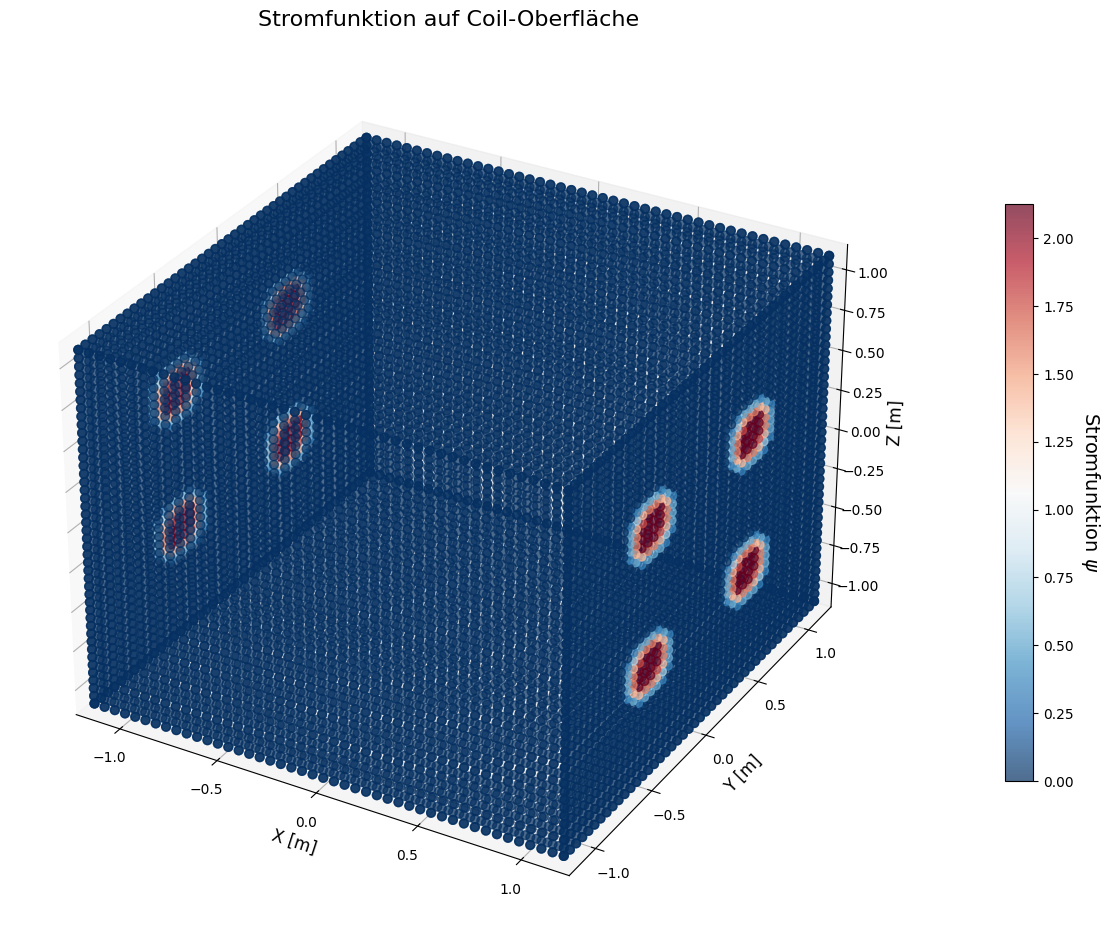

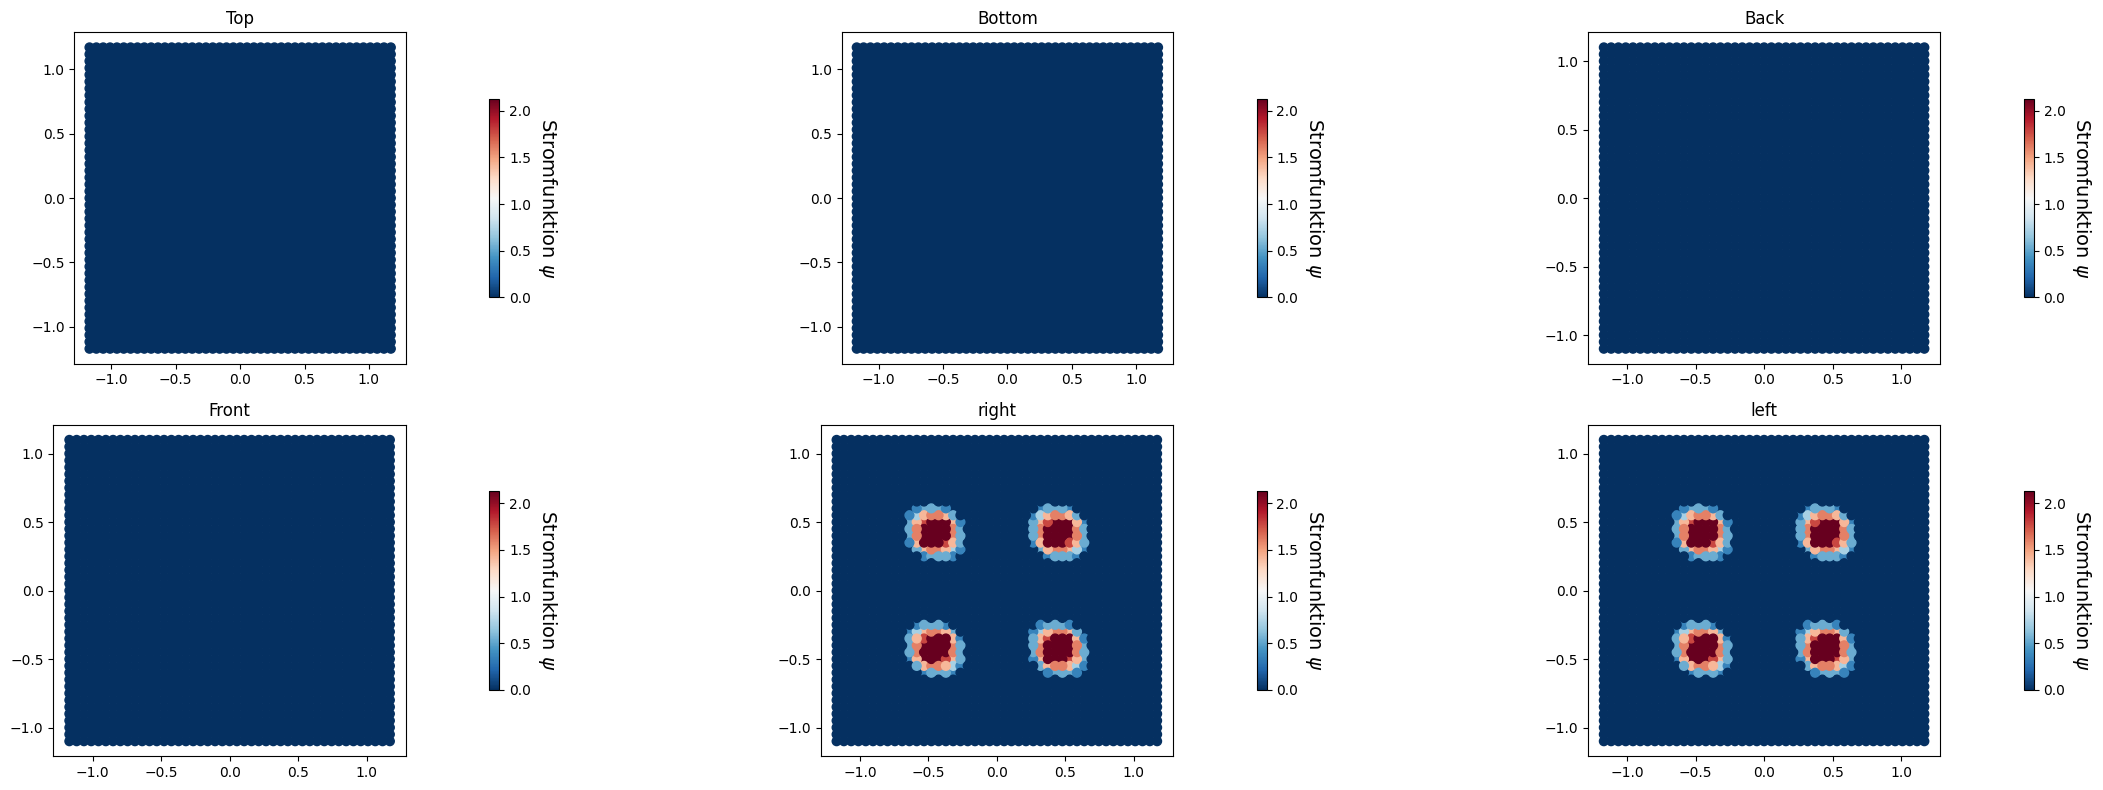

In [ ]:
fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_coil_coarse)

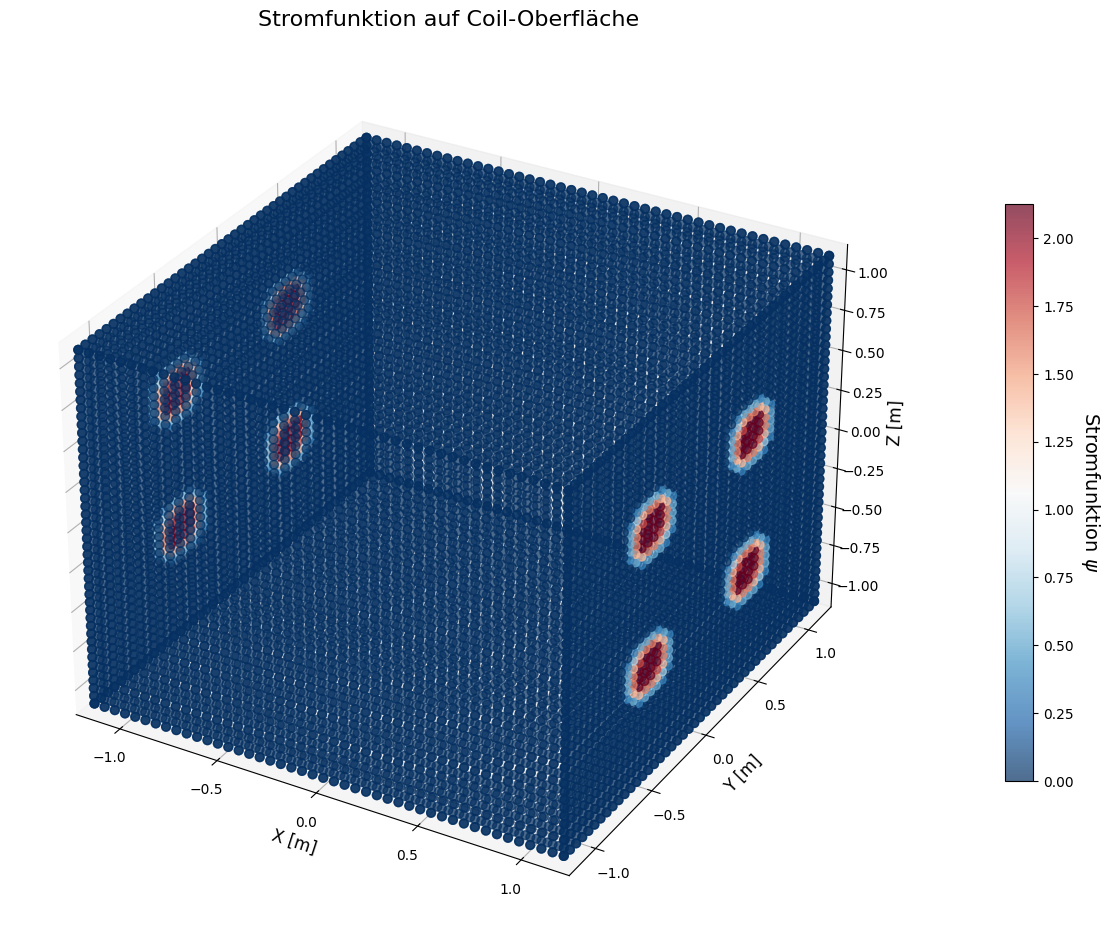

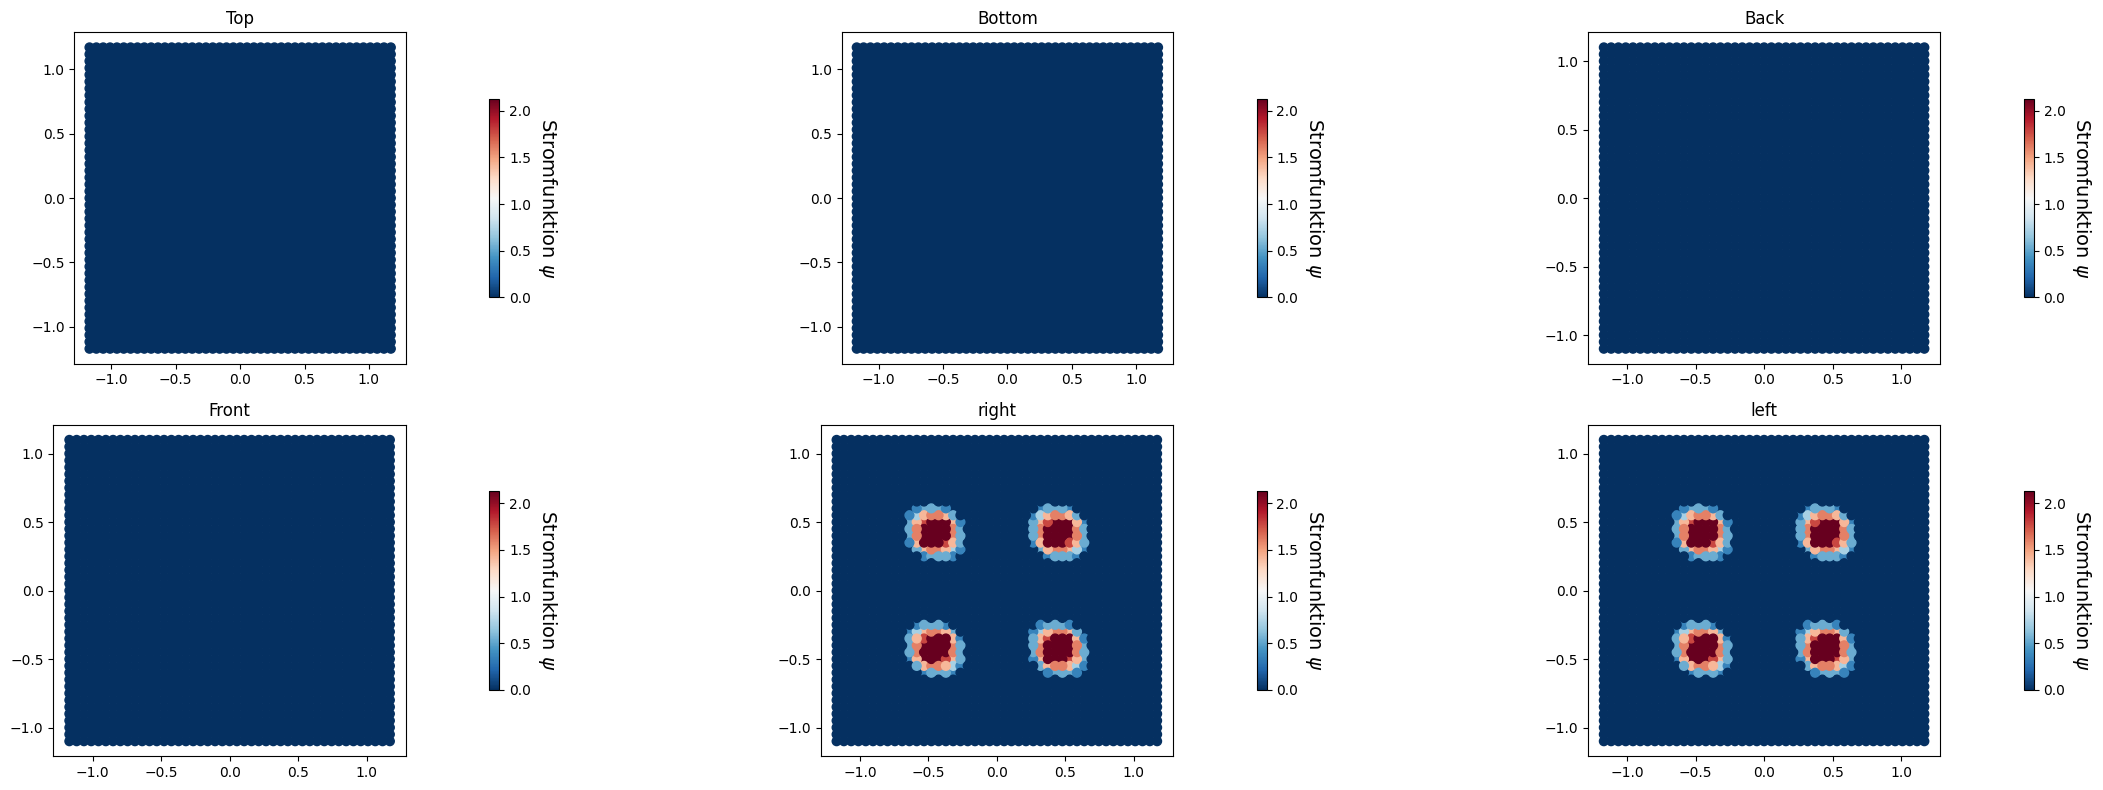

In [ ]:
fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_tot)

## Strom

Berechne den Strom aus der Streamfunction um nachzuprüfen, ob der Output sinnvoll ist.

Außerdem: Darüber nachdenken, ob ich das Problem rückwerts angehen kann, um direkt ein Ergebnis zu finden, und nicht über das B-Feld zu müssen.

Allgemein gilt:
\begin{gather}
    j(r) = \nabla_\parallel \psi(r) \text{ x } n(r) \\
    \psi(r)-\psi(r_0) = \int_{r_0}^r j(r')\cdot (dl' \text{ x } n')
\end{gather}

n = 45, dx = 0.21272727272727265
Shape of streamfunction: (12150,)
Shape of reshaped streamfunction: (6, 45, 45)
Shapes:
   J_u: (6, 45, 45)
   J_v: (6, 45, 45)
   U: (6, 45, 45)
   V: (6, 45, 45)
   W: (6, 45, 45)


c:\Users\grego\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
c:\Users\grego\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


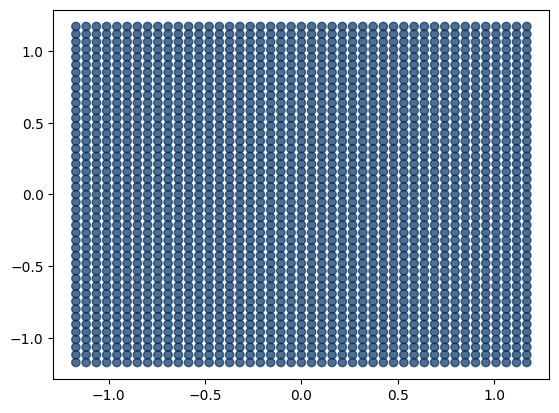

In [ ]:
n = int(np.sqrt(len(Coils.total_planes.vertices)/6))                                    # number of points in one row / column
dx = np.abs(Coils.total_planes.vertices[0][0] - Coils.total_planes.vertices[1][0])      # Distance between two adjacent vertices
dy = dx
print(f'n = {n}, dx = {dx}')

stream_func_reshaped = np.array(stream_func_coil_coarse).reshape(6, n, n)
print(f'Shape of streamfunction: {stream_func_coil_coarse.shape}\nShape of reshaped streamfunction: {stream_func_reshaped.shape}')

dpsi_du , dpsi_dv = np.gradient(stream_func_reshaped, dx, dy, axis = (1,2))

J_u = dpsi_dv
J_v = -dpsi_du

u = Coils.total_planes.vertices[:, 0]
v = Coils.total_planes.vertices[:, 1]
w = Coils.total_planes.vertices[:, 2]
u = u.reshape(6, n, n)
v = v.reshape(6, n, n)
w = w.reshape(6, n, n)

print(f'Shapes:\n   J_u: {J_u.shape}\n   J_v: {J_v.shape}\n   U: {u.shape}\n   V: {v.shape}\n   W: {w.shape}')

fig, ax = plt.subplots()
ax.scatter(u[0], 
           v[0],
           c = stream_func_reshaped[0],
           alpha = 0.7,
           cmap = 'RdBu_r')
ax.quiver(u[0], v[0], J_u[0], J_v[0])


In [ ]:
current_test = bfieldtools.mesh_calculus.gradient(stream_func_coil_coarse, Coils.total_planes, True)

print(current.shape)

n = int(len(Coils.total_planes.vertices)/6)
x = Coils.total_planes.vertices[0*n : 1*n, 0]
y = Coils.total_planes.vertices[0*n : 1*n, 1]
z = Coils.total_planes.vertices[0*n : 1*n, 2]
J_x = current_test[0, 0*n : 1*n]
J_y = current_test[1, 0*n : 1*n]
J_z = current_test[2, 0*n : 1*n]

print(x.shape, J_x.shape)


fig, ax = plt.subplots()
ax.scatter(x[0*n : 1*n], 
           y[0*n : 1*n],
           c = stream_func_coil_coarse[0*n : 1*n],
           alpha = 0.7,
           cmap = 'RdBu_r')
ax.quiver(x, y, J_x, J_y)



AttributeError: 'float' object has no attribute 'shape'